# 可视化模块演示 (Viz Module)

本notebook演示hscredit库中可视化模块的全部功能，包含8种可视化方法。

In [1]:
# 添加项目路径
import sys
import os
sys.path.append('../')

# 初始化设置
from hscredit.utils import init_setting
init_setting(seed=42)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
data_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/hscredit.xlsx'
df = pd.read_excel(data_path)
print(f"数据形状: {df.shape}")

数据形状: (12448, 85)


In [2]:
# 定义目标列和排除列
target_col = 'FPD15'
exclude_cols = ['MOB1', 'MOB2', 'loan_date', 'FPD15', 'SFPD15']

# 获取特征列
feature_cols = [col for col in df.columns if col not in exclude_cols]
demo_feature = feature_cols[0]
print(f"演示特征: {demo_feature}")

演示特征: bj_qy24


## 1. 导入可视化模块

In [3]:
from hscredit.core.viz import (
    bin_plot,
    corr_plot,
    ks_plot,
    hist_plot,
    psi_plot,
    dataframe_plot,
    distribution_plot,
    plot_weights
)

print("可视化模块导入成功！")

可视化模块导入成功！


## 2. 分箱图 (bin_plot)

展示特征分箱后的好坏样本分布和坏样本率。

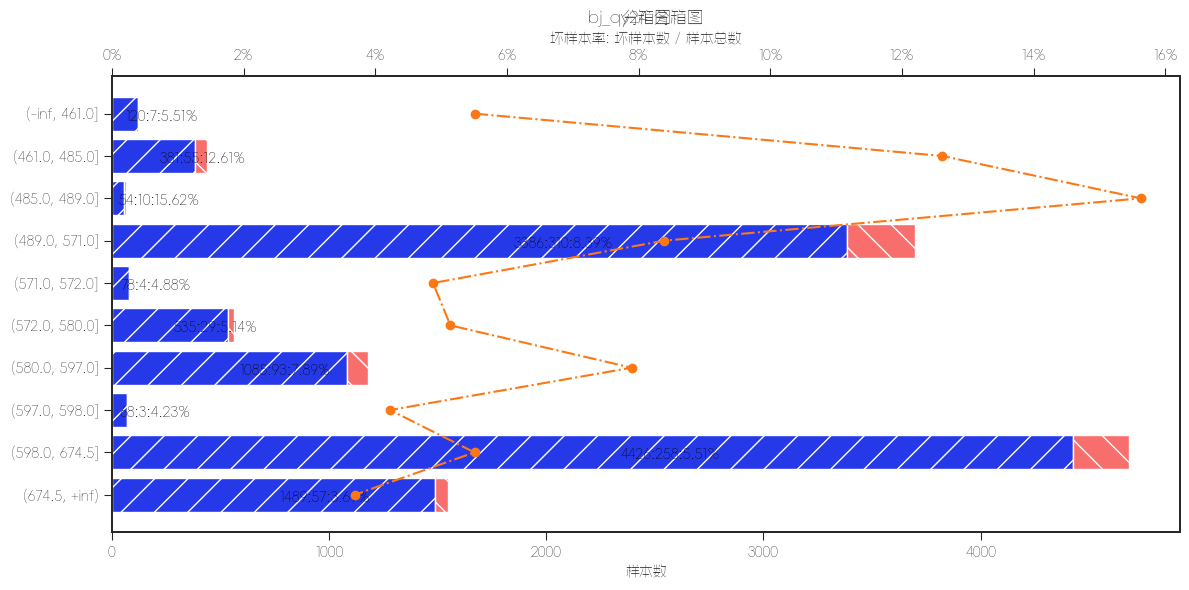

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_bin_plot.png


In [4]:
from hscredit.report.feature_analyzer import feature_bin_stats

# 计算分箱统计
stats = feature_bin_stats(df, feature=demo_feature, target=target_col, max_n_bins=10)

# 重命名列以匹配bin_plot期望的格式
stats_plot = stats.rename(columns={'分箱标签': '分箱'})

# 绘制分箱图
fig, ax = plt.subplots(figsize=(12, 6))
bin_plot(stats_plot, ax=ax)
plt.title(f'{demo_feature} 分箱图')
plt.tight_layout()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_bin_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 3. 相关性热力图 (corr_plot)

展示特征之间的相关性。

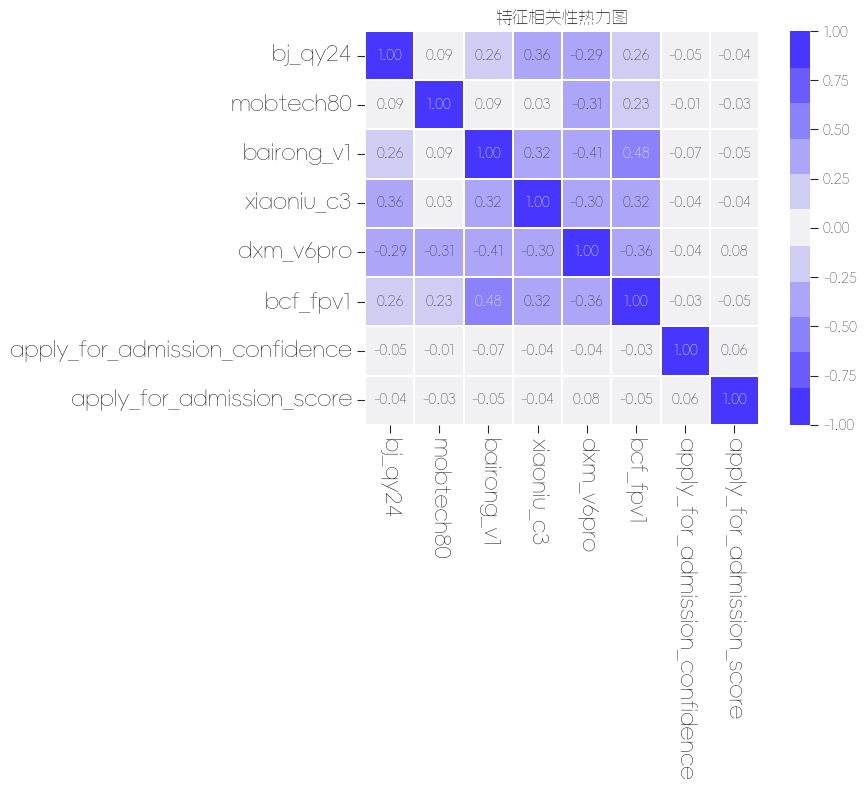

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_corr_plot.png


In [5]:
# 相关性热力图
fig, ax = plt.subplots(figsize=(10, 8))
corr_plot(df[feature_cols[:8]], ax=ax)
plt.title('特征相关性热力图')
plt.tight_layout()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_corr_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 4. 特征分布直方图 (hist_plot)

展示特征值的分布情况，区分好坏样本。

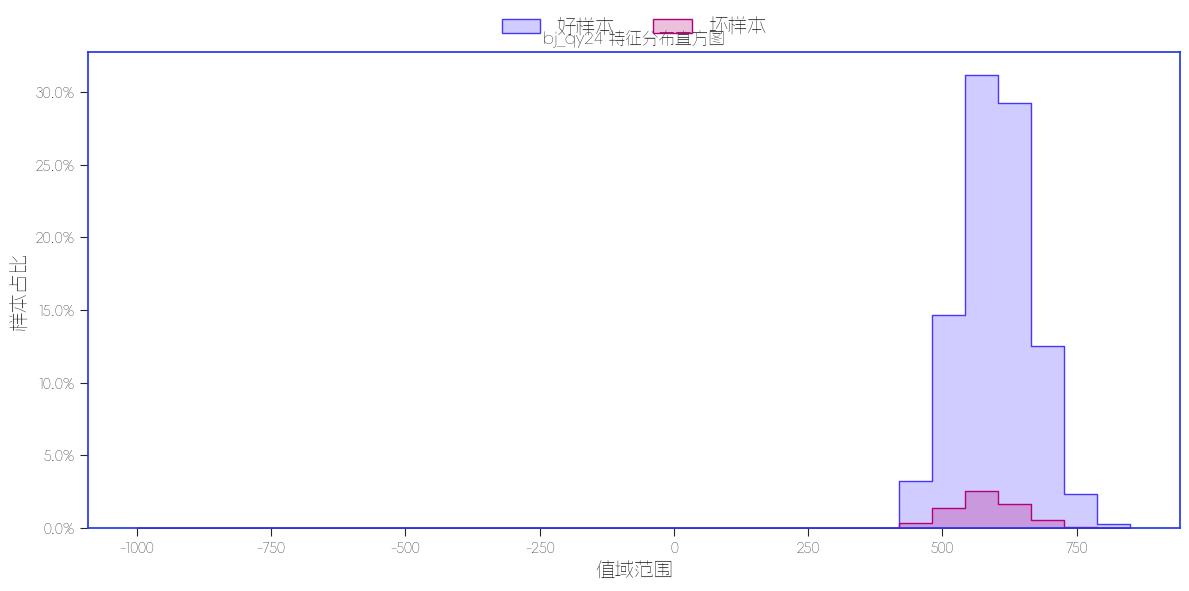

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_hist_plot.png


In [6]:
# 特征分布直方图
fig, ax = plt.subplots(figsize=(12, 6))
hist_plot(df[demo_feature], df[target_col], ax=ax)
plt.title(f'{demo_feature} 特征分布直方图')
plt.tight_layout()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_hist_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 5. 分布对比图

对比训练集和测试集的特征分布。

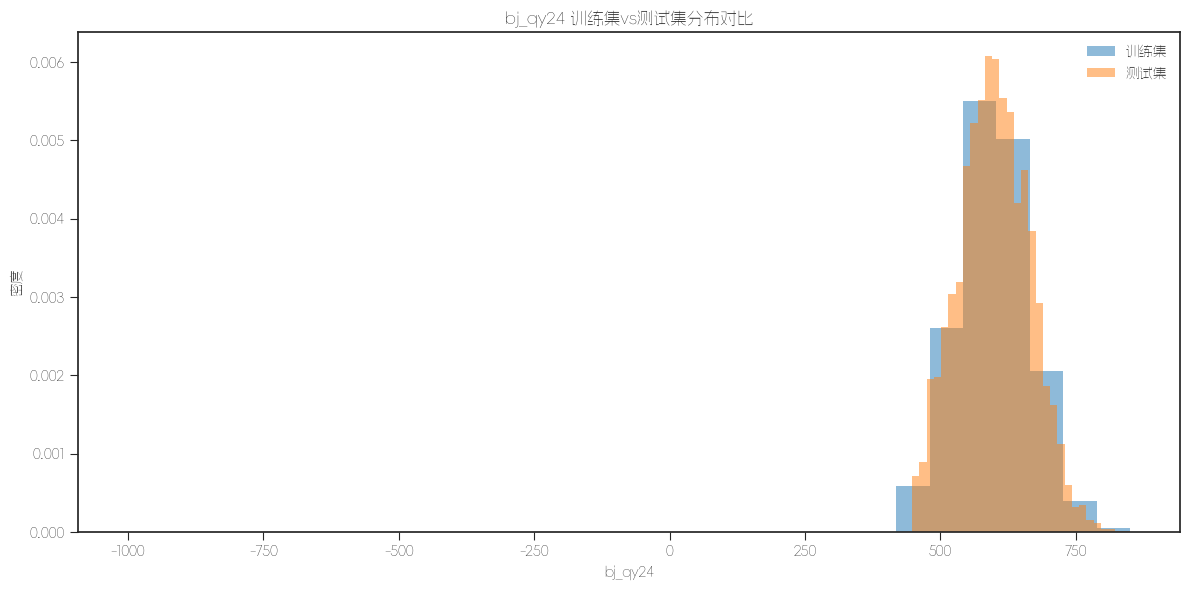

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_distribution_plot.png


In [7]:
from sklearn.model_selection import train_test_split

# 划分训练集和测试集
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 分布对比图
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(X_train[demo_feature].dropna(), bins=30, alpha=0.5, label='训练集', density=True)
ax.hist(X_test[demo_feature].dropna(), bins=30, alpha=0.5, label='测试集', density=True)
ax.set_xlabel(demo_feature)
ax.set_ylabel('密度')
ax.legend()
plt.title(f'{demo_feature} 训练集vs测试集分布对比')
plt.tight_layout()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_distribution_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 6. KS曲线图 (ks_plot)

展示模型的KS统计量和ROC曲线。

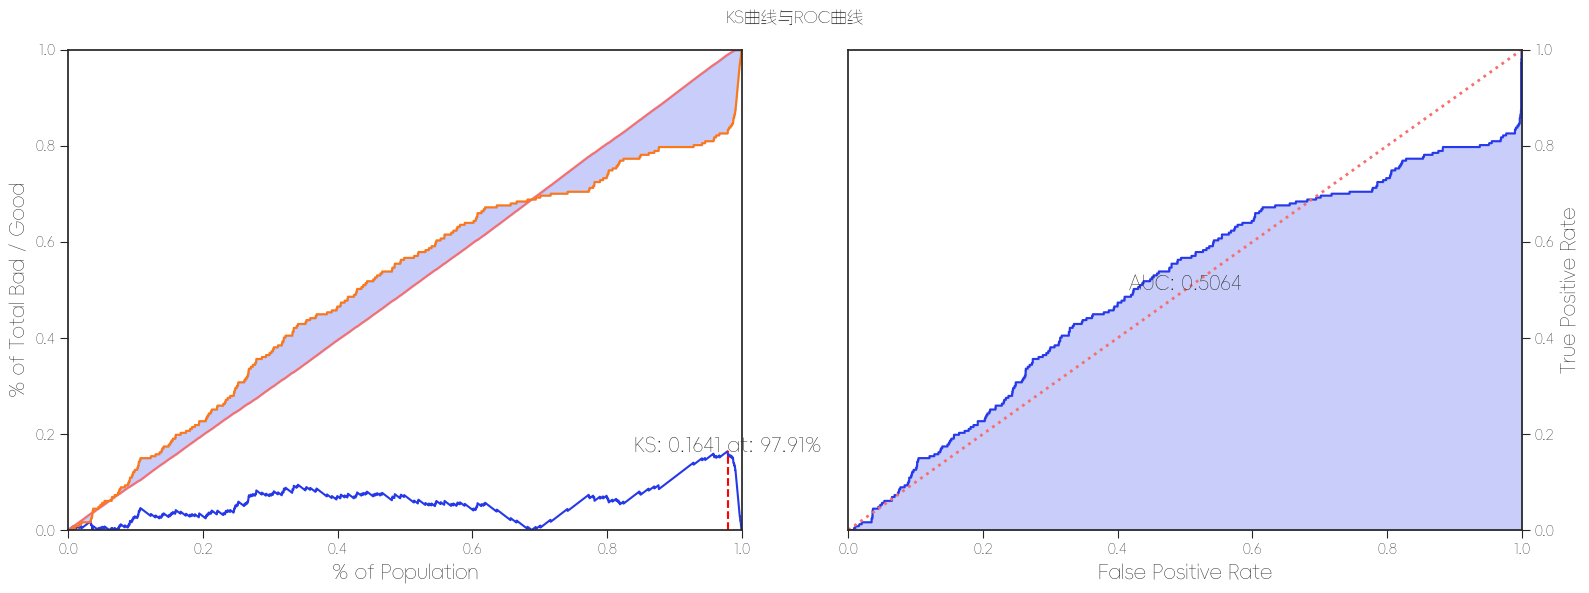

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_ks_plot.png


In [8]:
from hscredit.core.models import LogisticRegression
from hscredit.core.encoders import WOEEncoder

# WOE编码
woe = WOEEncoder()
X_train_woe = woe.fit_transform(X_train, y_train)
X_test_woe = woe.transform(X_test)

# 训练逻辑回归
lr = LogisticRegression(max_iter=1000, calculate_stats=True)
lr.fit(X_train_woe, y_train)
y_pred_proba = lr.predict_proba(X_test_woe)[:, 1]

# KS曲线图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ks_plot(y_pred_proba, y_test, axes=axes)
plt.suptitle('KS曲线与ROC曲线')
plt.tight_layout()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_ks_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 7. PSI稳定性图 (psi_plot)

展示训练集和测试集的群体稳定性指数(PSI)。

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_psi_plot.png


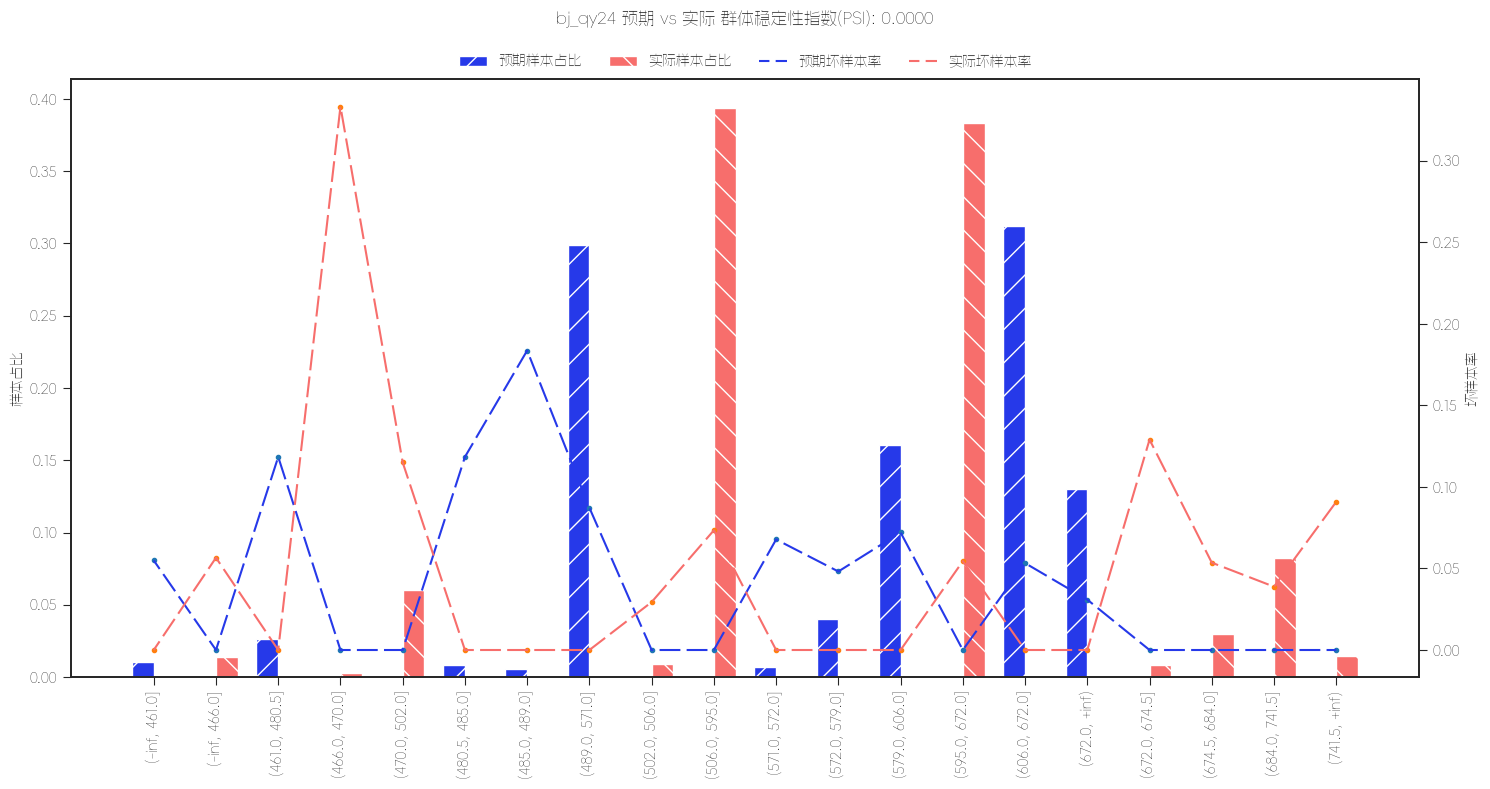

In [ ]:
# 计算分箱统计
train_df = X_train.copy()
train_df[target_col] = y_train
test_df = X_test.copy()
test_df[target_col] = y_test

train_stats = feature_bin_stats(train_df, feature=demo_feature, target=target_col, max_n_bins=10)
test_stats = feature_bin_stats(test_df, feature=demo_feature, target=target_col, max_n_bins=10)

# 重命名列以匹配psi_plot期望的格式
train_stats_psi = train_stats.rename(columns={'分箱标签': '分箱'})
test_stats_psi = test_stats.rename(columns={'分箱标签': '分箱'})

# 绘制PSI图
psi_plot(train_stats_psi, test_stats_psi, desc=demo_feature)

output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_psi_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"图片已保存至: {output_path}")

## 8. 逻辑回归系数图 (plot_weights)

展示逻辑回归模型的特征系数及其置信区间。

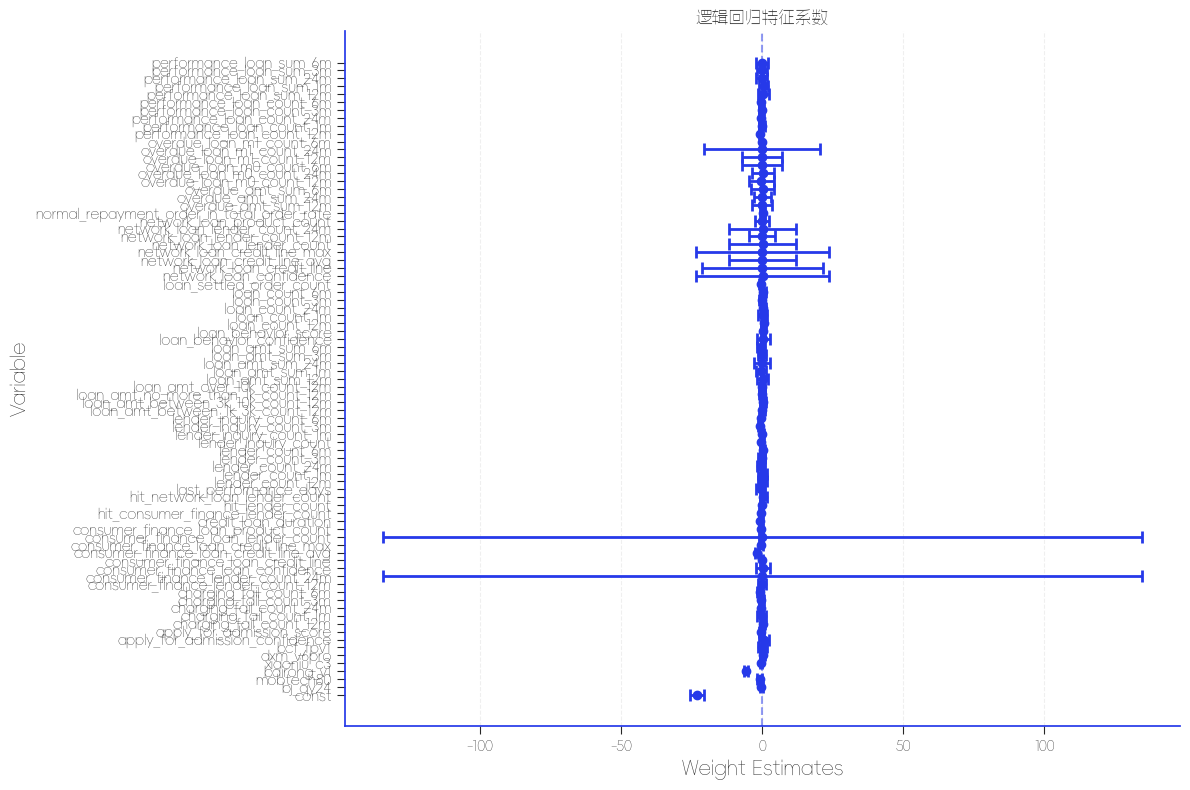

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_weights_plot.png


In [10]:
# 获取模型摘要
summary = lr.summary()

# 逻辑回归系数图
fig, ax = plt.subplots(figsize=(12, 8))
plot_weights(summary, ax=ax)
plt.title('逻辑回归特征系数')
plt.tight_layout()
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_weights_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 9. DataFrame表格图 (dataframe_plot)

将DataFrame以美观的表格形式展示。

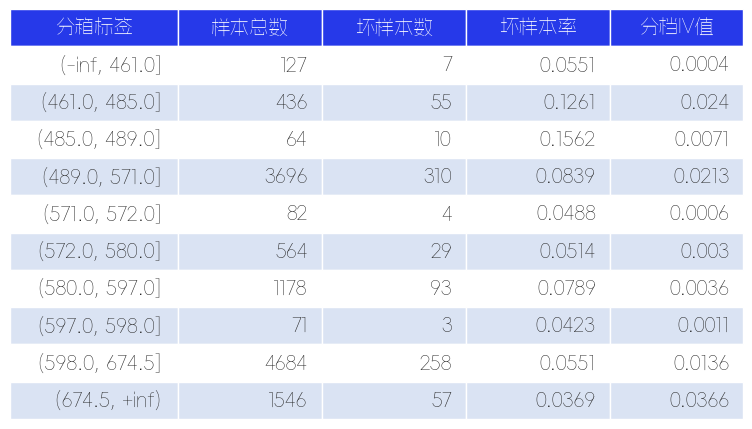

图片已保存至: /Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_dataframe_plot.png


In [15]:
# DataFrame表格图
sample_df = stats[['分箱标签', '样本总数', '坏样本数', '坏样本率', '分档IV值']].head(10)
fig = dataframe_plot(sample_df)
output_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/viz_dataframe_plot.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片已保存至: {output_path}")

## 10. 可视化结果汇总

In [12]:
# 可视化结果汇总
viz_files = [
    'viz_bin_plot.png',
    'viz_corr_plot.png',
    'viz_ks_plot.png',
    'viz_hist_plot.png',
    'viz_psi_plot.png',
    'viz_weights_plot.png',
    'viz_distribution_plot.png',
    'viz_dataframe_plot.png'
]

output_dir = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples'
print("生成的可视化文件:")
for f in viz_files:
    filepath = os.path.join(output_dir, f)
    if os.path.exists(filepath):
        print(f"  ✓ {f}")
    else:
        print(f"  ✗ {f} (未生成)")

生成的可视化文件:
  ✓ viz_bin_plot.png
  ✓ viz_corr_plot.png
  ✓ viz_ks_plot.png
  ✓ viz_hist_plot.png
  ✓ viz_psi_plot.png
  ✓ viz_weights_plot.png
  ✓ viz_distribution_plot.png
  ✓ viz_dataframe_plot.png
